# Quantum Error Visualizer

A toolkit for simulating and visualizing how quantum noise affects qubit states.

## Overview

This notebook demonstrates the five core modules:

| Module | Purpose |
|--------|----------|
| `states` | Create quantum states (kets and density matrices) |
| `channels` | Apply noise channels via Kraus operators |
| `simulate` | Generate trajectories through repeated noise application |
| `metrics` | Compute fidelity and purity measures |
| `visualize` | Plot Bloch spheres, fidelity decay, and density matrices |

In [1]:
import numpy as np
import qutip as qt
from matplotlib import rc

rc('animation', html='html5')

---

# 1. Module: `states`

## Physics Background

A **qubit** is a two-level quantum system. Its state can be described as:

$$|\psi\rangle = \cos\!\left(\frac{\theta}{2}\right)|0\rangle + e^{i\phi}\sin\!\left(\frac{\theta}{2}\right)|1\rangle$$

where $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi)$ are the **Bloch sphere angles**.

### Density Matrix
For mixed states (statistical ensembles), we use the **density matrix**:

$$\rho = |\psi\rangle\langle\psi|$$

This formalism is essential because noise channels produce mixed states from pure inputs.

In [2]:
from states import bloch_state, density_matrix, zero_state, one_state, plus_state, minus_state

## Standard Basis States

The computational basis states $|0\rangle$ and $|1\rangle$ are the eigenstates of the Pauli-Z operator.

In [3]:
print("|0\N{MATHEMATICAL RIGHT ANGLE BRACKET} =")
display(zero_state())

print("\n|1\N{MATHEMATICAL RIGHT ANGLE BRACKET} =")
display(one_state())

print("\n|+\N{MATHEMATICAL RIGHT ANGLE BRACKET} = (|0\N{MATHEMATICAL RIGHT ANGLE BRACKET} + |1\N{MATHEMATICAL RIGHT ANGLE BRACKET}) / sqrt(2) =")
display(plus_state())

print("\n|-\N{MATHEMATICAL RIGHT ANGLE BRACKET} = (|0\N{MATHEMATICAL RIGHT ANGLE BRACKET} - |1\N{MATHEMATICAL RIGHT ANGLE BRACKET}) / sqrt(2) =")
display(minus_state())

|0⟩ =


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]


|1⟩ =


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]


|+⟩ = (|0⟩ + |1⟩) / sqrt(2) =


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]


|-⟩ = (|0⟩ - |1⟩) / sqrt(2) =


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]

## Bloch Sphere States

Any pure single-qubit state maps to a point on the **Bloch sphere**:

- $\theta = 0$ → North pole ($|0\rangle$)
- $\theta = \pi$ → South pole ($|1\rangle$)
- $\theta = \pi/2$, $\phi = 0$ → Equator ($|+\rangle$)
- $\theta = \pi/2$, $\phi = \pi$ → Equator ($|-\rangle$)

In [4]:
state = bloch_state(theta=np.pi/3, phi=np.pi/4)
print("State at theta=pi/3, phi=pi/4:")
display(state)

State at theta=pi/3, phi=pi/4:


Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.8660254 +0.j        ]
 [0.35355339+0.35355339j]]

## Density Matrix Conversion

The `density_matrix()` function converts a ket $|\psi\rangle$ to a density matrix $\rho = |\psi\rangle\langle\psi|$. If the input is already a density matrix, it passes through unchanged.

In [5]:
rho = density_matrix(plus_state())
print("Density matrix of |+\N{MATHEMATICAL RIGHT ANGLE BRACKET}:")
display(rho)

print(f"\nTrace = {rho.tr().real:.1f} (must equal 1)")
print(f"Purity = {(rho*rho).tr().real:.4f} (1.0 for pure states)")

Density matrix of |+⟩:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]


Trace = 1.0 (must equal 1)
Purity = 1.0000 (1.0 for pure states)


---

# 2. Module: `channels`

## Physics Background

Quantum **noise channels** describe how a quantum state degrades through interaction with the environment. Mathematically, they are **completely positive trace-preserving (CPTP) maps**.

### Kraus Representation
Any CPTP map can be written as:

$$\mathcal{E}(\rho) = \sum_k K_k \rho K_k^\dagger$$

where the **Kraus operators** satisfy $\sum_k K_k^\dagger K_k = I$.

In [6]:
from channels import amplitude_damping, bit_flip, depolarizing, phase_damping, phase_flip

## 1. Depolarizing Channel

$$\mathcal{E}(\rho) = (1-p)\rho + p\frac{I}{2}$$

With probability $p$, the state is replaced by the maximally mixed state $I/2$. This models **uniform random errors** — the qubit is equally likely to flip in any direction on the Bloch sphere.

In [7]:
rho = density_matrix(plus_state())
print("Original |+\N{MATHEMATICAL RIGHT ANGLE BRACKET} state:")
display(rho)

channel = depolarizing(p=0.3)
rho_noisy = channel(rho)
print("\nAfter depolarizing (p=0.3):")
display(rho_noisy)

Original |+⟩ state:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]


After depolarizing (p=0.3):


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5  0.35]
 [0.35 0.5 ]]

## 2. Bit-Flip Channel

Kraus operators: $K_0 = \sqrt{1-p}\, I$, $K_1 = \sqrt{p}\, X$

Applies a Pauli-X (NOT) error with probability $p$. This flips $|0\rangle \leftrightarrow |1\rangle$, analogous to classical bit errors.

In [8]:
rho = density_matrix(zero_state())
print("Original |0\N{MATHEMATICAL RIGHT ANGLE BRACKET} state:")
display(rho)

channel = bit_flip(p=0.5)
rho_noisy = channel(rho)
print("\nAfter bit-flip (p=0.5) — fully mixed on equator:")
display(rho_noisy)

Original |0⟩ state:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]


After bit-flip (p=0.5) — fully mixed on equator:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]

## 3. Phase-Flip Channel

Kraus operators: $K_0 = \sqrt{1-p}\, I$, $K_1 = \sqrt{p}\, Z$

Applies a Pauli-Z error with probability $p$. This introduces a relative phase between $|0\rangle$ and $|1\rangle$ without flipping the qubit. It is the **quantum analog of dephasing**.

In [9]:
rho = density_matrix(plus_state())
print("Original |+\N{MATHEMATICAL RIGHT ANGLE BRACKET} state:")
display(rho)

channel = phase_flip(p=0.5)
rho_noisy = channel(rho)
print("\nAfter phase-flip (p=0.5):")
display(rho_noisy)

Original |+⟩ state:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]


After phase-flip (p=0.5):


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]

## 4. Amplitude Damping Channel

Kraus operators:
$$K_0 = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-\gamma} \end{pmatrix}, \quad K_1 = \begin{pmatrix} 0 & \sqrt{\gamma} \\ 0 & 0 \end{pmatrix}$$

Models **energy dissipation** ($T_1$ decay): the excited state $|1\rangle$ spontaneously decays to $|0\rangle$ with rate $\gamma$. On the Bloch sphere, the state spirals toward the north pole.

In [10]:
rho = density_matrix(one_state())
print("Original |1\N{MATHEMATICAL RIGHT ANGLE BRACKET} state (excited):")
display(rho)

channel = amplitude_damping(gamma=0.5)
rho_noisy = channel(rho)
print("\nAfter amplitude damping (gamma=0.5):")
display(rho_noisy)
print("\n→ The state has partially decayed toward |0\N{MATHEMATICAL RIGHT ANGLE BRACKET}")

Original |1⟩ state (excited):


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0.]
 [0. 1.]]


After amplitude damping (gamma=0.5):


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]


→ The state has partially decayed toward |0⟩


## 5. Phase Damping Channel

Kraus operators: $K_0 = \sqrt{1-p}\, I$, $K_1 = \sqrt{p}\, |0\rangle\langle 0|$, $K_2 = \sqrt{p}\, |1\rangle\langle 1|$

Models **pure dephasing** ($T_2$ decay): the off-diagonal elements of the density matrix shrink, destroying quantum coherence without affecting populations. On the Bloch sphere, the state contracts toward the Z-axis.

In [11]:
rho = density_matrix(plus_state())
print("Original |+\N{MATHEMATICAL RIGHT ANGLE BRACKET} state:")
display(rho)

channel = phase_damping(p=0.4)
rho_noisy = channel(rho)
print("\nAfter phase damping (p=0.4):")
display(rho_noisy)
print("\n→ Off-diagonal elements reduced; state contracts toward Z-axis")

Original |+⟩ state:


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]]


After phase damping (p=0.4):


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.3]
 [0.3 0.5]]


→ Off-diagonal elements reduced; state contracts toward Z-axis


---

# 3. Module: `simulate`

## Physics Background

To study noise effects, we repeatedly apply a channel to see how the state evolves over time. This generates a **trajectory** through the space of density matrices.

The trajectory function takes:
- An initial state $\rho_0$
- A noise channel $\mathcal{E}$
- A number of steps $n$

and produces: $\rho_0, \mathcal{E}(\rho_0), \mathcal{E}^2(\rho_0), \ldots, \mathcal{E}^n(\rho_0)$

In [12]:
from simulate import trajectory, trajectory_no_tqdm

In [13]:
rho0 = bloch_state(theta=np.pi/3, phi=np.pi/4)
channel = amplitude_damping(gamma=0.1)

states = trajectory(rho0, channel, steps=30)
print(f"Generated {len(states)} states ({len(states)-1} noise applications)")

100%|██████████| 30/30 [00:00<00:00, 7793.69it/s]

Generated 31 states (30 noise applications)


---

# 4. Module: `metrics`

## Physics Background

### Fidelity
Fidelity measures how close a noisy state $\rho$ is to the original pure state $|\psi_0\rangle$:

$$F(\rho_0, \rho) = \langle\psi_0|\rho|\psi_0\rangle$$

- $F = 1$: perfect preservation
- $F = 0$: orthogonal (completely lost)

### Purity
Purity quantifies how "pure" (non-mixed) a state is:

$$\gamma = \text{Tr}(\rho^2)$$

- $\gamma = 1$: pure state
- $\gamma = 1/d$: maximally mixed state (for dimension $d$)

For qubits, $\gamma = 1$ is pure and $\gamma = 0.5$ is maximally mixed.

In [14]:
from metrics import fidelity_curve, purity_curve

In [15]:
fidelities = fidelity_curve(rho0, states)
purities = purity_curve(states)

print(f"Initial fidelity: {fidelities[0]:.4f}")
print(f"Final fidelity:   {fidelities[-1]:.4f}")
print(f"\nInitial purity: {purities[0]:.4f}")
print(f"Final purity:   {purities[-1]:.4f}")

Initial fidelity: 1.0000
Final fidelity:   0.9066

Initial purity: 1.0000
Final purity:   0.9949


---

# 5. Module: `visualize`

This module provides four visualization tools for quantum state evolution.

In [16]:
from visualize import bloch_rotating_animation, bloch_trajectory, density_matrix_plot, fidelity_plot

## Bloch Sphere Trajectory

The Bloch sphere is a geometric representation of single-qubit states:
- Pure states lie on the surface
- Mixed states lie inside the sphere
- The state vector is: $\vec{r} = (\langle\sigma_x\rangle, \langle\sigma_y\rangle, \langle\sigma_z\rangle)$

This plot shows how the state moves under repeated noise application.

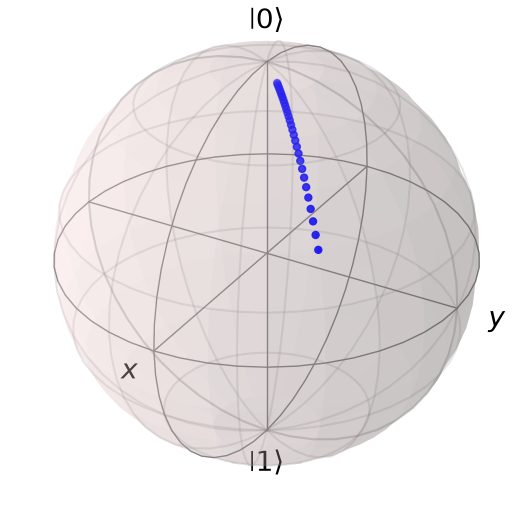

In [17]:
bloch_trajectory(states)

## Fidelity Decay Plot

Shows how the overlap between the current state and the initial state decreases over time. The decay rate depends on the noise strength $p$.

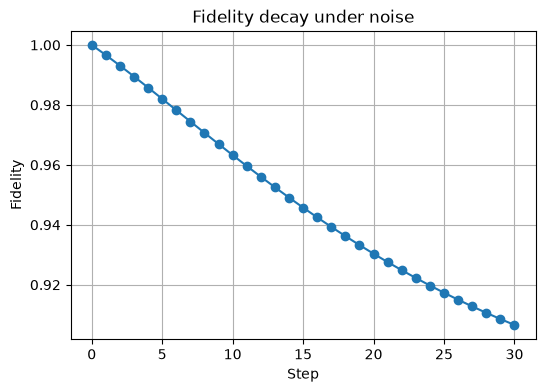

In [18]:
fidelity_plot(fidelities)

## Density Matrix Visualization

Plots the real and imaginary parts of the density matrix as heatmaps.

### How to read the plot

The density matrix for a qubit is:

$$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$$

- **Diagonal** ($\rho_{00}$, $\rho_{11}$): the **populations** — probability of being in $|0\rangle$ or $|1\rangle$. These are always real and non-negative.
- **Off-diagonal** ($\rho_{01}$, $\rho_{10}$): the **coherences** — encode the quantum superposition between $|0\rangle$ and $|1\rangle$. These can be complex (hence the imaginary part plot).



Initial state:


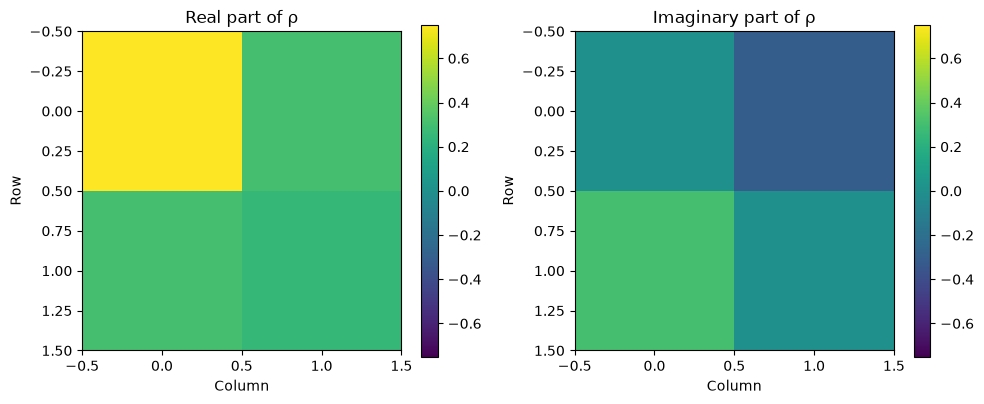


Final state (after 30 amplitude damping steps):


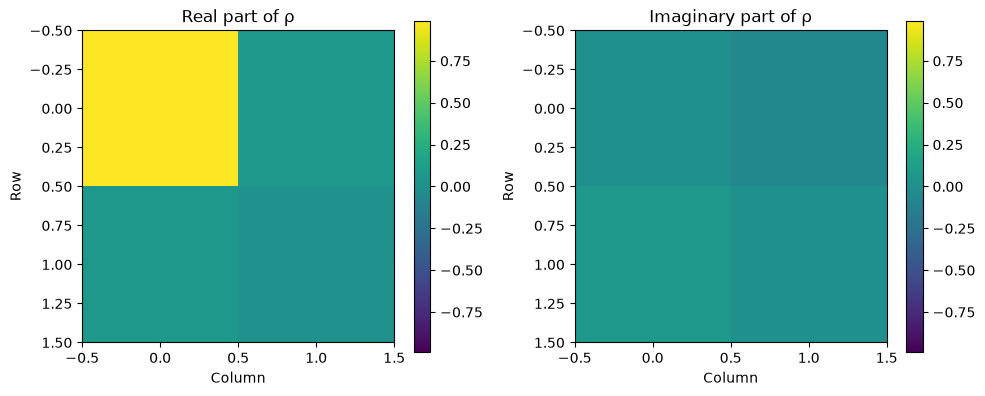

In [24]:
print("Initial state:")
density_matrix_plot(states[0])

print("\nFinal state (after 30 amplitude damping steps):")
density_matrix_plot(states[-1])

## Animated Bloch Sphere

An animated version showing the qubit state evolving with a rotating camera view.

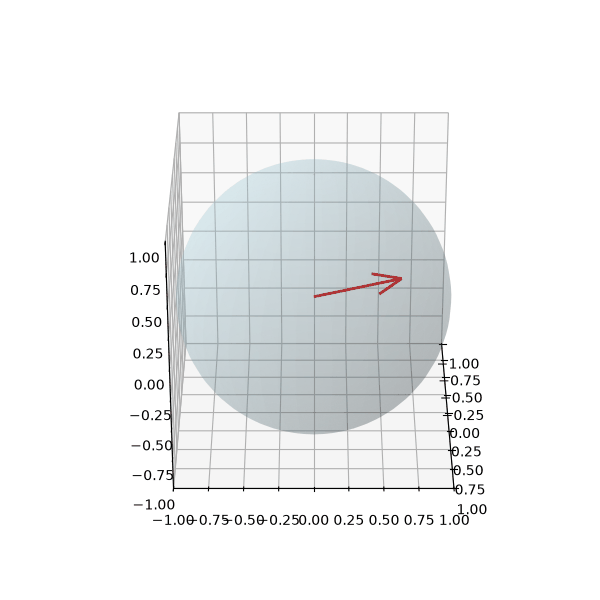

In [25]:
from matplotlib.animation import PillowWriter

ani = bloch_rotating_animation(states)
ani.save("animation.gif", writer=PillowWriter(fps=10))

from IPython.display import Image
Image(filename="animation.gif")

---

# Putting It All Together: Comparing Noise Channels

Let's compare how different noise channels affect the same initial state.

In [21]:
rho0 = bloch_state(theta=np.pi/3, phi=np.pi/4)
steps = 30

channels_to_test = {
    "Depolarizing (p=0.1)": depolarizing(0.1),
    "Bit-flip (p=0.1)": bit_flip(0.1),
    "Phase-flip (p=0.1)": phase_flip(0.1),
    "Amplitude damping (gamma=0.1)": amplitude_damping(0.1),
    "Phase damping (p=0.1)": phase_damping(0.1),
}

100%|██████████| 30/30 [00:00<00:00, 8134.80it/s]


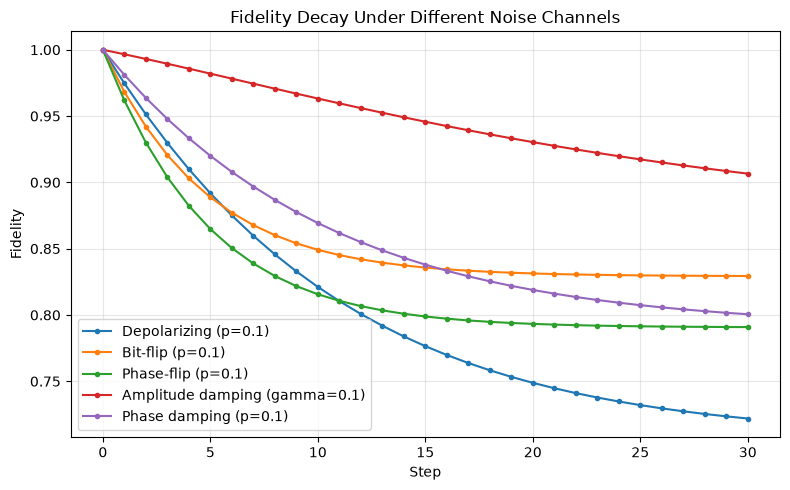

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for name, ch in channels_to_test.items():
    states_i = trajectory(rho0, ch, steps)
    fids = fidelity_curve(rho0, states_i)
    ax.plot(fids, label=name, marker='o', markersize=3)

ax.set_xlabel("Step")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity Decay Under Different Noise Channels")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

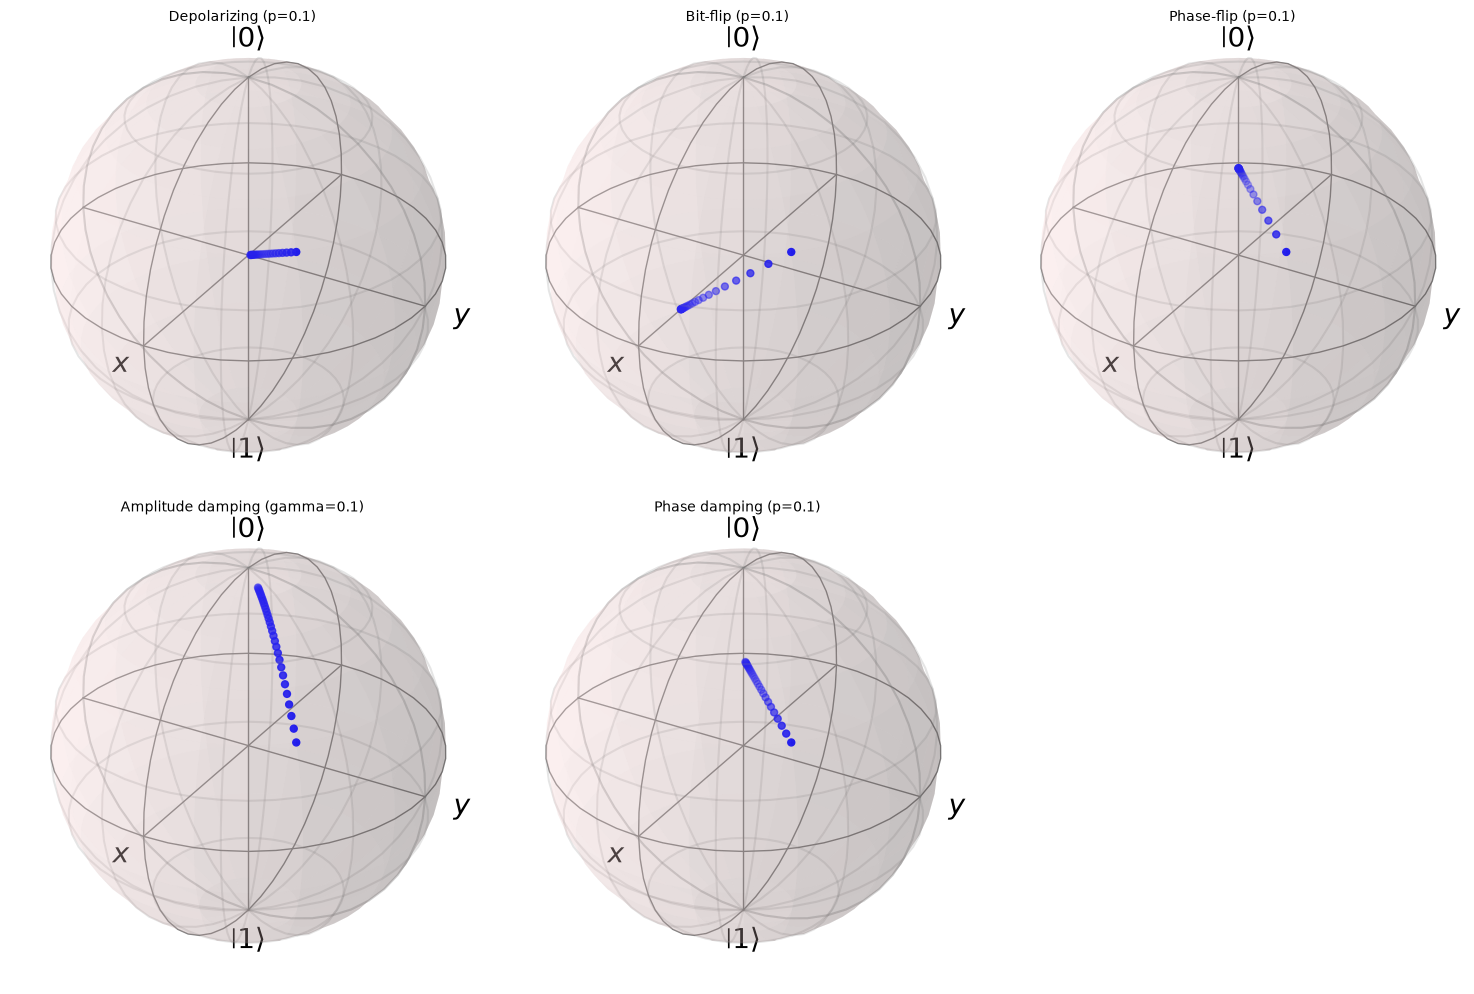

In [23]:
fig = plt.figure(figsize=(15, 10))

for idx, (name, ch) in enumerate(channels_to_test.items(), 1):
    states_i = trajectory_no_tqdm(rho0, ch, steps)
    vecs = np.array([
        [(s * qt.sigmax()).tr().real, (s * qt.sigmay()).tr().real, (s * qt.sigmaz()).tr().real]
        for s in states_i
    ])
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    b = qt.Bloch(fig=fig, axes=ax)
    b.add_points(vecs.T)
    b.make_sphere()
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

---

# Summary

| Channel | Effect on Bloch Sphere | Physical Process |
|---------|----------------------|------------------|
| Depolarizing | Shrinks toward center | Uniform random errors |
| Bit-flip | Shrinks along X | Classical bit flips |
| Phase-flip | Shrinks along Z | Dephasing |
| Amplitude damping | Moves toward north pole | Energy decay ($T_1$) |
| Phase damping | Contracts toward Z-axis | Pure dephasing ($T_2$) |